In [900]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import os
import scipy
import pickle
import random

from neurolib.models.aln import ALNModel
from neurolib.models.rate_control import RateModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.getcwd()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [835]:
def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:2,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:2,i_time] = maxI_
    return control_

In [836]:
def setinitvars(vars):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = vars[sv]
                else:
                    aln.params[init_vars[iv]][:] = vars[sv]
                    

In [837]:
tol = 1e-32

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

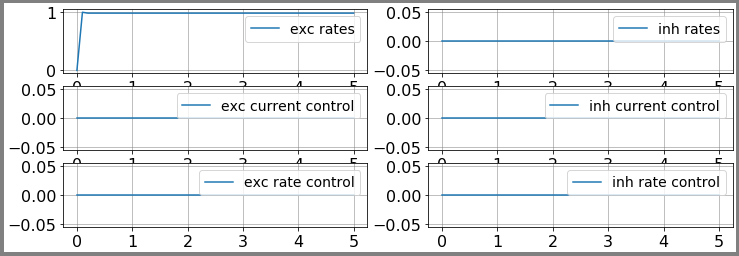

In [890]:
aln = RateModel()

aln.params['duration'] = 5.
aln.params.dt = 0.1
control0 = aln.getZeroControl()

# NO ADAPTATION
aln.params.IA_init = np.array([0.])
aln.params.a = 0.
aln.params.b = 0.

# no noise
aln.params.sigma_ou = 0.
aln.params.mue_ext_mean = 0.
aln.params.mui_ext_mean = 0.
aln.params.sigmae_ext = 0.
aln.params.sigmai_ext = 0.
aln.params.ext_exc_current = 0.
aln.params.ext_inh_current = 0.

# no delay
aln.params.signalV = 0.
aln.params.de = 0.
aln.params.di = 0.

aln.params.cie = 1.
aln.params.Jie_max = 1.
aln.params.tau_se = 1.
aln.params.tau_si = 1.
aln.params.C = 1.
aln.params.gL = 1.
aln.params.Ke = 1000.
aln.params.Ki = 1000.

plotFunc.plot_traces(aln, control0)

output = aln.output_vars

state_vars = aln.state_vars
init_vars = aln.init_vars

high_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        high_state_vars[i] = aln.state[state_vars[i]][0]
    else:
        high_state_vars[i] = aln.state[state_vars[i]][0,-2]

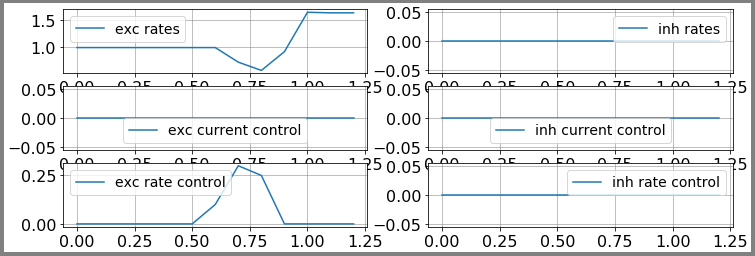

no delay : 
exc rates :  [0.98520605 0.98520605 0.98520605 0.98520605 0.98520605 0.98520605
 0.98520605 0.71630386 0.56424479 0.90989225 1.6363215  1.62566675
 1.62582136]
inh rates :  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
[[[0.98520605 0.98520605 0.98520605 0.71630386 0.56424479 0.90989225
   1.6363215  1.62566675 1.62582136]
  [0.         0.         0.         0.         0.         0.
   0.         0.         0.        ]]]


In [914]:
dur = 0.8
dur_pre = 0.4
dur_post = 0.4

n_dur = int(dur/aln.params.dt + 1)
n_pre = int(dur_pre/aln.params.dt + 1)

aln.params.duration = dur + dur_pre

control_ind = [2]
prec_var = [0]

if control_ind[0] == 0 or control_ind[0] == 1:
    max_cntrl = 5.
    min_cntrl = -5.
else:
    max_cntrl = 0.5
    min_cntrl = - 0.5

control0 = aln.getZeroControl()
#control0[0,control_ind,:] =  np.sin(np.arange(0,dur+1, 1))
#control0[0,control_ind,0] = 1.
for j in control_ind:
    #control0[0,j,n_pre + 0] = 1.0 * max_cntrl - 0.0 * min_cntrl
    control0[0,j,n_pre + 1] = 0.2 * max_cntrl #- 0.2 * min_cntrl
    control0[0,j,n_pre + 2] = 0.6 * max_cntrl #- 0.2 * min_cntrl
    control0[0,j,n_pre + 3] = 0.5 * max_cntrl #- 0.0 * min_cntrl
    #control0[0,j,n_pre + 4] = 1.0 * max_cntrl - 0.2 * min_cntrl
    #control0[0,j,n_pre + 5] = 0.5 * max_cntrl - 0.6 * min_cntrl
    #control0[0,j,n_pre + 6] = 1.0 * max_cntrl - 0.8 * min_cntrl

#control0[0,1,:] = 0.    

setinitvars(high_state_vars)

aln.params.de = 0.
plotFunc.plot_traces(aln, control0)
print("no delay : ")
print("exc rates : ", aln.rates_exc[0,:])
print("inh rates : ", aln.rates_inh[0,:])

aln.params.duration = dur
target = aln.getZeroTarget()
target[0,0,:] = aln.rates_exc[0,n_pre-1:]
target[0,1,:] = aln.rates_inh[0,n_pre-1:]

print(aln.state["siev"])
print(target)

control1 = aln.getZeroControl()
for k in range(1, control1.shape[2]-1):
    control1[0,j,k] += random.uniform(0., 1.) * max_cntrl

In [922]:
costparams = [1. * 1e0, 0.* 1e-3, 0.* 1e-3]
cost.setParams(costparams[0], costparams[1], costparams[2])

setinitvars(high_state_vars)
max_it = 100
start_step = 10.
alg = "A1"
case = "test"

aln.params.duration = dur
control1 = aln.getZeroControl()
control2 = bestControlA[:,:,n_pre-1:-n_pre+1]
control3 = control0[:,:,n_pre-1:]
control3[0,2,3] += 0.01

cvar = [None, "HS", "FR", "PR", "HZ"]
cgv = cvar[0]

bestControlA, bestStateA, costA, runtimeA, grad = aln.A1(control1, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, 
        min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
        CGVar = cgv, control_variables_ = control_ind, prec_variables_ = prec_var)

for j in control_ind:
    print("control ind ", j )
    print("grad = ", grad[0,j,:])
    print("best control = ", bestControlA[0,j,:])

for i in range(1, len(costA)):
    if costA[i-1] < costA[i]:
        print("ERROR ---------------- in index ", i)
        
print("total runtime = ", runtimeA[-1])
# 3.810394756896814

set cost params
RUN  0 , total integrated cost =  0.07498590775808914
t, phi 9, 15 =  0 1.1500578046492933 -5.749324517396376e-05
t, phi 9, 15 =  1 1.1461715368951921 0.0038862677541010838
t, phi 9, 15 =  2 1.4088646065047925 -0.26269306960960037
t, phi 9, 15 =  3 1.8285712205552078 -0.4197066140504153
t, phi 9, 15 =  4 1.913379494349969 -0.08480827379476111
t, phi 9, 15 =  5 1.2715987813168992 0.6417807130330697
t, phi 9, 15 =  6 0.6406153119740182 0.6309834693428811
t, phi 9, 15 =  7 0.0 0.6406153119740182
t, phi 9, 15 =  8 0.0 0.0
RUN  1 , total integrated cost =  0.007774504107006124
t, phi 9, 15 =  0 -0.3246528480838802 0.12887239919152296
t, phi 9, 15 =  1 -0.4117582689062908 0.0871054208224106
t, phi 9, 15 =  2 -0.2994038211156712 -0.11235444779061958
t, phi 9, 15 =  3 -0.01862124075532169 -0.28078258036034953
t, phi 9, 15 =  4 0.11937729231819545 -0.13799853307351712
t, phi 9, 15 =  5 -0.0030317888487465527 0.122409081166942
t, phi 9, 15 =  6 -0.05208233398314022 0.049050545134

t, phi 9, 15 =  0 -0.24921086549274202 -0.038885426577956336
t, phi 9, 15 =  1 -0.2144498100374255 -0.03476105545531651
t, phi 9, 15 =  2 -0.16520160648723903 -0.04924820355018646
t, phi 9, 15 =  3 -0.04101141309721305 -0.12419019339002596
t, phi 9, 15 =  4 -0.009999065880093501 -0.031012347217119544
t, phi 9, 15 =  5 -0.006314703831887401 -0.003684362048206101
t, phi 9, 15 =  6 -0.003170793039245723 -0.003143910792641677
t, phi 9, 15 =  7 0.0 -0.003170793039245723
t, phi 9, 15 =  8 0.0 0.0
RUN  20 , total integrated cost =  0.0010886901609834145
t, phi 9, 15 =  0 -0.24927629739789894 -0.039020802606131166
t, phi 9, 15 =  1 -0.21440665836874856 -0.03486963902915039
t, phi 9, 15 =  2 -0.16511365774166104 -0.049293000627087524
t, phi 9, 15 =  3 -0.041015385677300675 -0.12409827206436035
t, phi 9, 15 =  4 -0.010005852586426939 -0.031009533090873738
t, phi 9, 15 =  5 -0.006314037584572404 -0.003691815001854535
t, phi 9, 15 =  6 -0.003162905269698424 -0.0031511323148739807
t, phi 9, 15 =  7

t, phi 9, 15 =  0 -0.25008947371113877 -0.0407627096708995
t, phi 9, 15 =  1 -0.2138342583277871 -0.03625521538335169
t, phi 9, 15 =  2 -0.1639571239569133 -0.049877134370873794
t, phi 9, 15 =  3 -0.04107051231056551 -0.1228866116463478
t, phi 9, 15 =  4 -0.01009623830831111 -0.0309742740022544
t, phi 9, 15 =  5 -0.006314001397311234 -0.003782236910999876
t, phi 9, 15 =  6 -0.003077343052664272 -0.0032366583446469623
t, phi 9, 15 =  7 0.0 -0.003077343052664272
t, phi 9, 15 =  8 0.0 0.0
RUN  40 , total integrated cost =  0.0010886689452162862
t, phi 9, 15 =  0 -0.25012709076206924 -0.040846302857414335
t, phi 9, 15 =  1 -0.21380592268916374 -0.03632116807290551
t, phi 9, 15 =  2 -0.16390038303217638 -0.04990553965698736
t, phi 9, 15 =  3 -0.04107332350368757 -0.1228270595284888
t, phi 9, 15 =  4 -0.010100696268739306 -0.030972627234948265
t, phi 9, 15 =  5 -0.006314360207197521 -0.0037863360615417846
t, phi 9, 15 =  6 -0.003073914993689142 -0.003240445213508379
t, phi 9, 15 =  7 0.0 -0.

t, phi 9, 15 =  0 -0.2516405887821567 -0.04452268930426247
t, phi 9, 15 =  1 -0.2124671575053738 -0.039173431276782925
t, phi 9, 15 =  2 -0.1612758152555479 -0.051191342249825876
t, phi 9, 15 =  3 -0.041208227795315175 -0.12006758746023274
t, phi 9, 15 =  4 -0.010303652743683958 -0.030904575051631217
t, phi 9, 15 =  5 -0.006355135995614646 -0.003948516748069311
t, phi 9, 15 =  6 -0.002970785995615177 -0.0033843499999994683
t, phi 9, 15 =  7 0.0 -0.002970785995615177
t, phi 9, 15 =  8 0.0 0.0
t, phi 9, 15 =  0 -0.2519188189215884 -0.04529034433531784
t, phi 9, 15 =  1 -0.21216176031423023 -0.039757058607358196
t, phi 9, 15 =  2 -0.16069222036272537 -0.051469539951504856
t, phi 9, 15 =  3 -0.041238757423173934 -0.11945346293955143
t, phi 9, 15 =  4 -0.010347233829826618 -0.030891523593347316
t, phi 9, 15 =  5 -0.006368730274419373 -0.003978503555407246
t, phi 9, 15 =  6 -0.0029589677913897106 -0.003409762483029662
t, phi 9, 15 =  7 0.0 -0.0029589677913897106
t, phi 9, 15 =  8 0.0 0.0
t, 

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
Improved over  72  iterations by  99.48933874164325  percent.
Problem in initial value trasfer:  sigmae_f 0.0 0.9871956516963454
Problem in initial value trasfer:  sigmae_f 0.0 1.2197556429968865
control ind  2
grad =  [ 0.15192219  0.12297684  0.00772798 -0.03474082 -0.05106715 -0.02001062
 -0.01630424  0.00243431  0.        ]
best control =  [ 0.          0.          0.          0.         -0.00053687 -0.00213832
  0.07828464  0.21026534  0.13489419 -0.05055538 -0.05995599 -0.06900165
  0.          0.          0.          0.          0.        ]
total runtime =  0.0


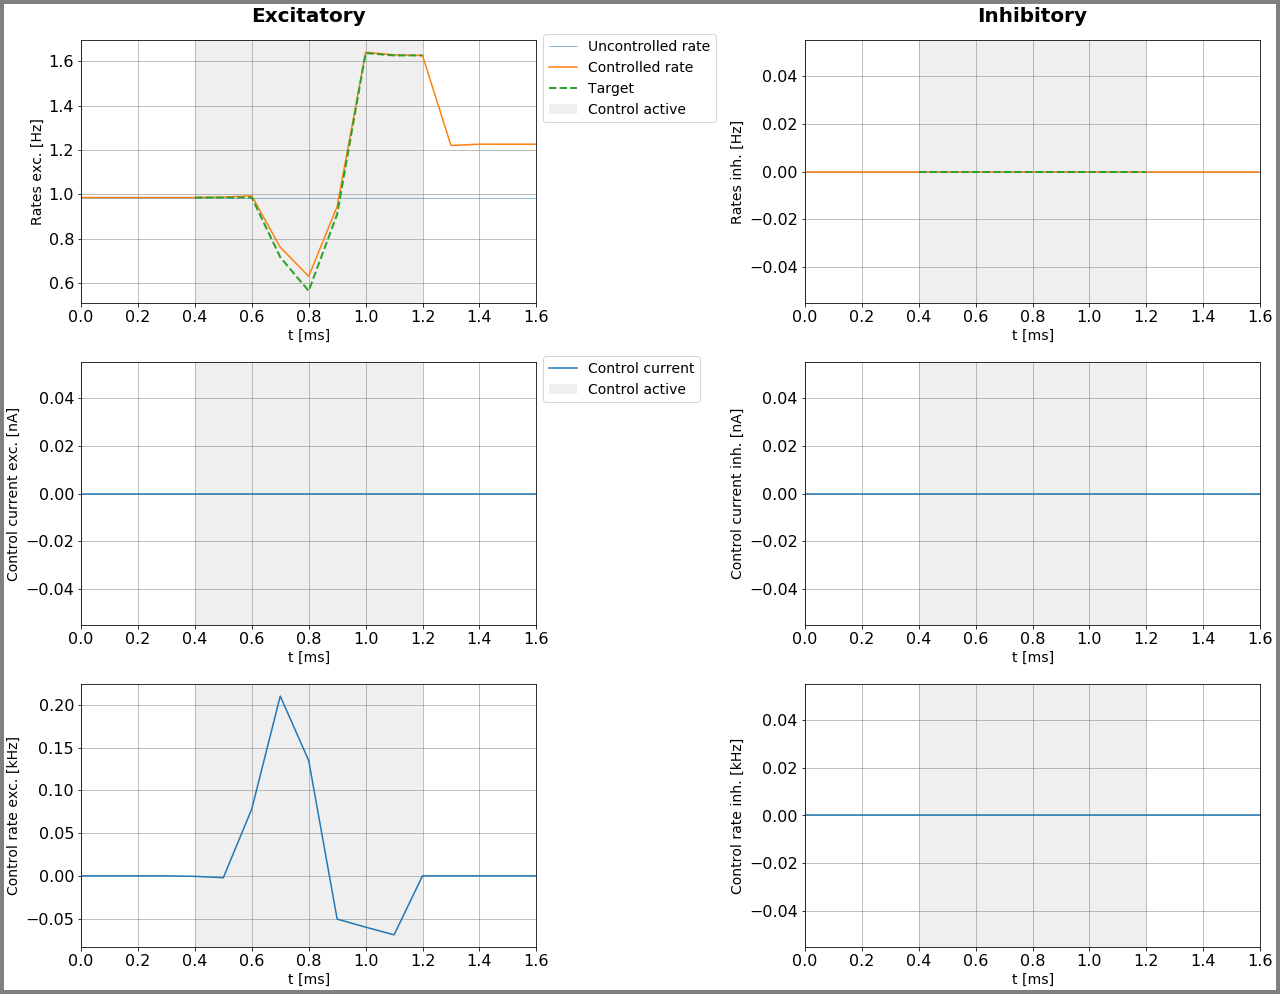

In [923]:
plotFunc.plot_control(aln, bestControlA, dur, dur_pre, dur_post, high_state_vars, target, path)

### Test cases

- [] precision only, c0-p0, no delay
- [] precision only, c0-p0, delay
- [] precision only, c0-p1, no delay
- [] precision only, c0-p1, delay
- [] precision only, c1-p1, no delay
- [] precision only, c1-p1, delay
- [] precision only, c1-p0, no delay
- [] precision only, c1-p0, delay
- [] precision only, c2-p0, no delay
- [] precision only, c2-p0, no delay
- [] precision only, c2-p1, delay
- [] precision only, c2-p1, delay

- [] p+e+s, c0-p0, no delay
- [] p+e+s, c0-p0, delay
- [] p+e+s, c0-p1, no delay
- [] p+e+s, c0-p1, delay
- [] p+e+s, c1-p1, no delay
- [] p+e+s, c1-p1, delay
- [] p+e+s, c1-p0, no delay
- [] p+e+s, c1-p0, delay
- [] p+e+s, c2-p0, no delay
- [] p+e+s, c2-p0, no delay
- [] p+e+s, c2-p1, delay
- [] p+e+s, c2-p1, delay

In [833]:
cost.setParams(costparams[0], costparams[1], costparams[2])
setinitvars(high_state_vars)
max_it = 10
start_step = 1.
alg = "A2"
case = "test"
incl_step = 10
test_step = 1e-6

aln.params.duration = dur
control3 = aln.getZeroControl()
#control4 = bestControlA_A2[:,:,n_pre-1:-n_pre+1]


print(max_cntrl, min_cntrl)

bestControlA_A2, bestStateA_A2, costA_A2, runtimeA_A2 = aln.A2(control3, target,
        max_iteration_ = max_it,  tolerance_ = tol, include_timestep_ = incl_step,
        start_step_ = start_step, test_step_ = test_step, max_control_ = max_cntrl,
        min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre,
        t_sim_post_ = dur_post, control_variables_ = control_ind, prec_variables_ = prec_var)

for i in range(1, len(costA_A2)):
    if costA_A2[i-1] < costA_A2[i]:
        print("ERROR ---------------- in index ", i)

set cost params
1.0 0.0
RUN  0 , total integrated cost:  5.952039202460933
RUN  1 , total integrated cost:  0.08203887342181887
RUN  2 , total integrated cost:  0.00021107802448258674
RUN  3 , total integrated cost:  6.628711077293317e-05
RUN  4 , total integrated cost:  3.9253662452426375e-05
State only changes marginally.
RUN  9 , total integrated cost:  3.858466241876079e-05
Improved over  9  iterations by  99.9993517404522  percent.


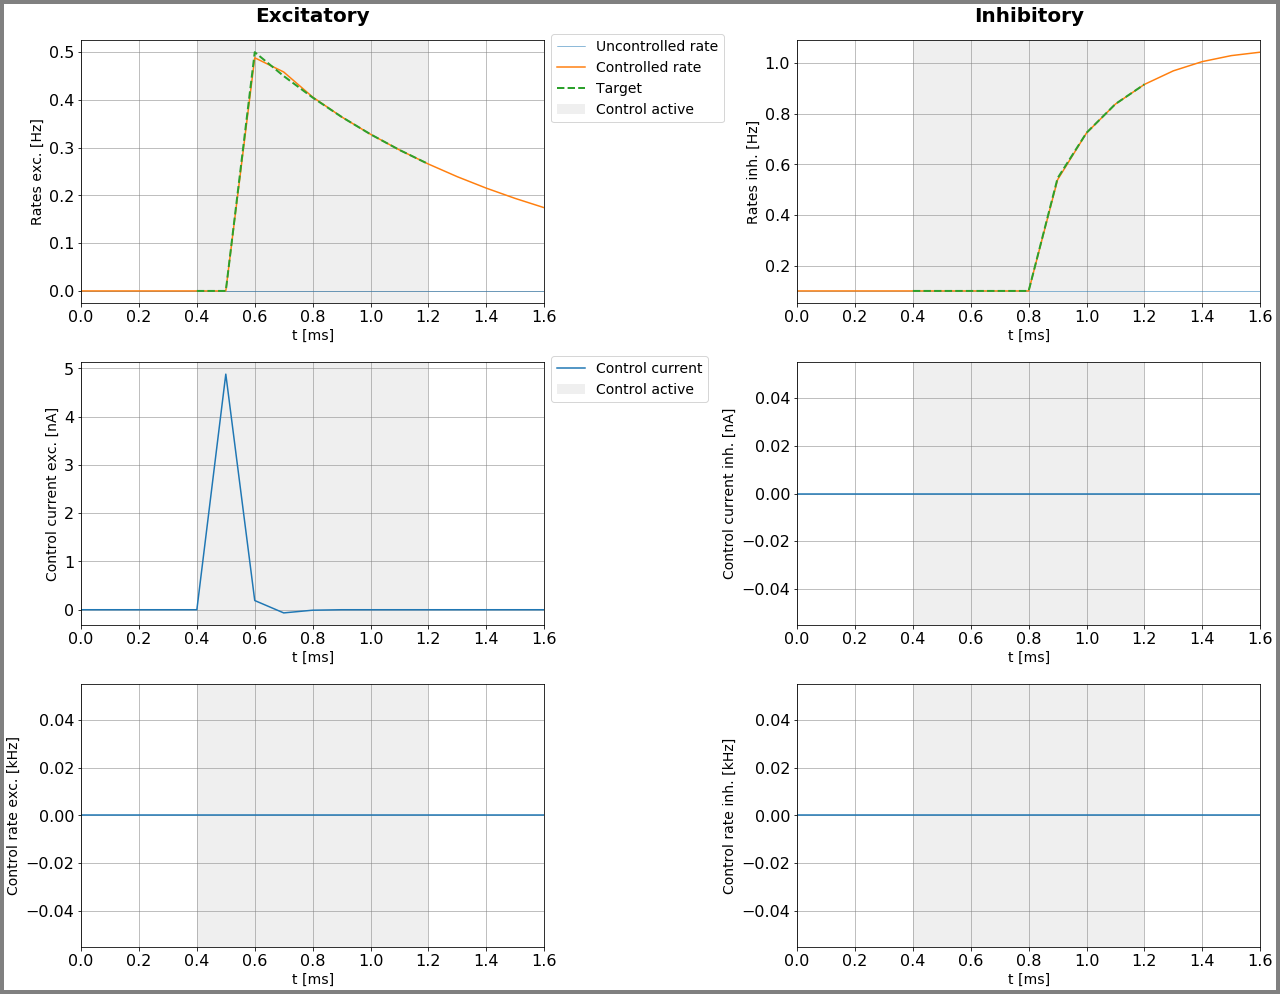

In [404]:
plotFunc.plot_control(aln, bestControlA_A2, dur, dur_pre, dur_post, high_state_vars, target, path)

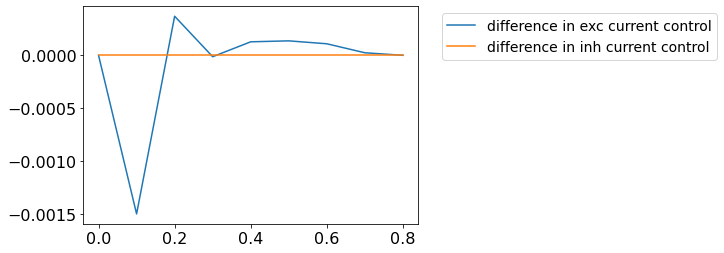

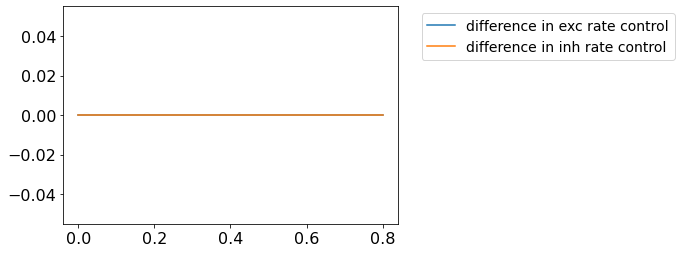

In [114]:
diff = bestControlA - bestControlA_A2
#diff[0,2,-2:] = 0.

#c_diff = costA_A2[6] - costA[3]
#print(c_diff)

t = np.arange(0,dur+0.1, 0.1)

plt.plot(t, diff[0,0,:], label="difference in exc current control")
plt.plot(t, diff[0,1,:], label="difference in inh current control")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

plt.plot(t, diff[0,2,:], label="difference in exc rate control")
plt.plot(t, diff[0,3,:], label="difference in inh rate control")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

### Testcases

1. PRECISION ONLY, NO DELAY
    - [x] 0 control, 0 precision measure, no delay
    - [x] 1 control, 1 precision measure, no delay
    - [x] 0 control, 1 precision measure, no delay
    - [x] 1 control, 0 precision measure, no delay
    - [] 2 control, 0 precision measure, no delay (slow to converge)
    - [] 2 control, 1 precision measure, no delay (slow to converge)

2. PRECISON + ENERGY + SPARSITY, NO DELAY
    - [x] 0 control, 0 precision measure, no delay
    - [x] 1 control, 1 precision measure, no delay
    - [] 0 control, 1 precision measure, no delay (requires different weights, gradient vanishes, A2 performes differently and worse)
    - [] 1 control, 0 precision measure, no delay (requires different weights, gradient vanishes, A2 performes differently and worse)
    - [x] 2 control, 0 precision measure, no delay
    - [] 2 control, 1 precision measure, no delay (requires different weights, zero control as output, gradient nonvanishing because on boundary. At higher weights, gradient vanishes)
    
3. PRECISION ONLY, DELAY
    - [x] 0 control, 0 precision measure, delay
    - [x] 1 control, 1 precision measure, delay
    - [] 0 control, 1 precision measure, delay (not in every case, could have several solutions)
    - [] 1 control, 0 precision measure, delay (not in every case, could have several solutions)
    - [x] 2 control, 0 precision measure, delay (sometimes slow convergence)
    - [x] 2 control, 1 precision measure, delay (sometimes slow to converge)

4. PRECISON + ENERGY + SPARSITY
    - [] 0 control, 0 precision measure, delay (gradient does not quite vanish)
    - [] 1 control, 1 precision measure, delay (gradient does not quite vanish)
    - [] 0 control, 1 precision measure, delay (requires different weights, gradient does not quite vanish, A2 performes differently and worse)
    - [] 1 control, 0 precision measure, delay (requires different weights, gradient does not quite vanish, A2 performes differently and worse)
    - [] 2 control, 0 precision measure, delay (gradient does not quite vanish)
    - [] 2 control, 1 precision measure, delay (requires different weights, gradient does not quite vanish, A2 performes differently and worse)
    
The cost functional should always have more than one minimum. If the "direct" control (0,0; 1,1; 2,0; 3,1) is not applied, it is much more likely to end up in a local minimum, because there is no "dominant" contribution.